In [133]:
import math
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [150]:
class Net(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.depth = len(layers) - 1
        self.activation = nn.Tanh()

        # Build the network architecture
        layer_list = []
        for i in range(self.depth - 1):
            layer_list.append(nn.Linear(layers[i], layers[i+1]))
            layer_list.append(self.activation)
        layer_list.append(nn.Linear(layers[-2], layers[-1]))

        self.net = nn.Sequential(*layer_list)

    def forward(self, y):
        return self.net(y)

Consider the following ODE with domain $t \in [0, \pi]$ and $\alpha = 1000$:
$$
\frac{dy}{dt} = -\alpha (y - \sin(t)) + \cos(t) \\
y(0) = 0
$$

The exact solution is function $y(t) = \sin(t)$

In [151]:
torch.manual_seed(42)
np.random.seed(42)

In [159]:
# --- Collocation points ---
alpha = 1000
N_f = 50
t_f = (torch.rand(N_f, 1) * math.pi).requires_grad_(True)
sin_t_f = (torch.sin(t_f)).detach()
cos_t_f = (torch.cos(t_f)).detach()

# --- Boundary points ---
t_bc = torch.tensor([[0.0]])
# --- Exact solution and analysis ---
y_exact_train = (torch.sin(t_f)).detach()
relative_l2_error = {}
mse_error = {}
l_inf_error = {}

In [160]:
# --- Initialize the network ---
layers = [1, 20, 20, 1]
adamNet = Net(layers)
optimizer = optim.Adam(adamNet.parameters(), lr=1e-3)

relative_l2_error["Standard"] = []
mse_error["Standard"] = []
l_inf_error["Standard"] = []

# --- Training loop ---
adam_epochs = 5000
start = time.time()
for epoch in range(adam_epochs):
    optimizer.zero_grad()

    # Wipe the input gradients alongside the optimizer!
    if t_f.grad is not None: t_f.grad.zero_()

    # --- Compute the ODE residual ---
    y_pred = adamNet(t_f)
    y_x = torch.autograd.grad(y_pred.sum(), t_f, create_graph=True)[0]

    residual = y_x + alpha*(y_pred - sin_t_f) - cos_t_f
    loss_ode = torch.mean(residual**2)

    # --- Compute the boundary loss ---
    u_bc_pred = adamNet(t_bc)
    loss_bc = torch.mean(u_bc_pred**2)

    # --- Total loss ---
    loss = loss_ode + loss_bc

    # --- Backpropagation ---
    loss.backward()
    optimizer.step()

    # Compute errors at current epoch
    relative_l2_error["Standard"].append(torch.sqrt(torch.mean((y_pred - y_exact_train)**2)).item() / torch.sqrt(torch.mean(y_exact_train**2)).item())
    mse_error["Standard"].append(torch.mean((y_pred - y_exact_train)**2).item())
    l_inf_error["Standard"].append(torch.max(torch.abs(y_pred - y_exact_train)).item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.7f}")

print(f'Training completed in {time.time() - start:.2f} seconds')

Epoch 0, Loss: 735284.3750000
Epoch 1000, Loss: 664.4025269
Epoch 2000, Loss: 54.3427238
Epoch 3000, Loss: 3.3593478
Epoch 4000, Loss: 1.2276319
Training completed in 2.16 seconds


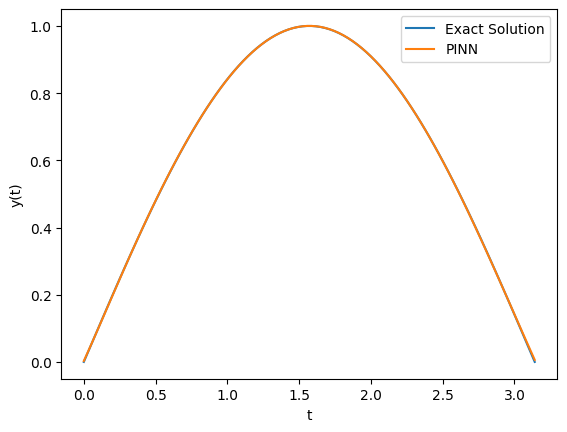

In [161]:
x_test = torch.linspace(0, math.pi, 100).reshape(-1, 1)

with torch.no_grad():
    u_pred_adam = adamNet(x_test)
    u_exact_vis = torch.sin(x_test)

plt.plot(x_test, u_exact_vis, label="Exact Solution")
plt.plot(x_test, u_pred_adam, label="PINN")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.show()

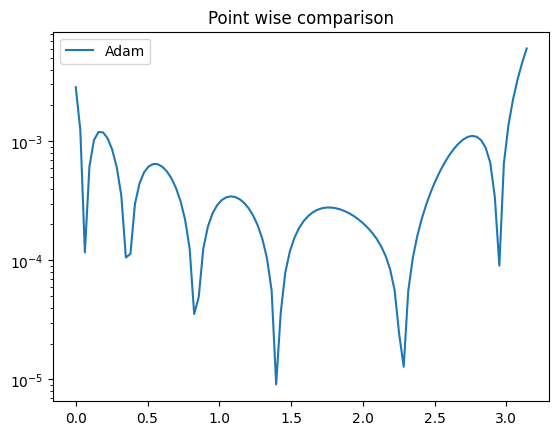

In [162]:
plt.semilogy(x_test, abs(u_pred_adam - u_exact_vis), label="Adam")
plt.title("Point wise comparison")
plt.legend()
plt.show()

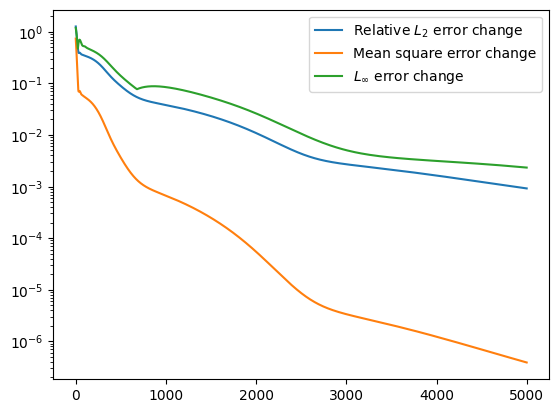

In [163]:
plt.semilogy(np.arange(0, adam_epochs), relative_l2_error["Standard"], label=r"Relative $L_2$ error change")
plt.semilogy(np.arange(0, adam_epochs), mse_error["Standard"], label="Mean square error change")
plt.semilogy(np.arange(0, adam_epochs), l_inf_error["Standard"], label=r"$L_{\infty}$ error change")
plt.legend()
plt.show()

In [164]:
final_relative_l2_error = torch.norm(u_pred_adam - u_exact_vis) / torch.norm(u_exact_vis)
print(f"Relative L2 error: {final_relative_l2_error.item()}")
final_mse_error = torch.mean((u_pred_adam - u_exact_vis)**2)
print(f"MSE: {final_mse_error.item()}")
final_l_inf_error = torch.max(torch.abs(u_pred_adam - u_exact_vis))
print(f"L_inf error: {final_l_inf_error.item()}")

Relative L2 error: 0.0014712739503011107
MSE: 1.0715002645156346e-06
L_inf error: 0.006015060469508171
